In [4]:
import numpy as np
import os
import random
from skimage.io import imread 
import matplotlib.pyplot as plt
import pickle
import cv2

In [2]:
path_test_images = "./images/faces_webface_112x112/imgs/"
INPUT = (112, 112, 3)

test_files = random.sample(os.listdir(path_test_images), 1000)

true_pairs = test_files[:500]
false_pairs = test_files[500:]

In [12]:
## Positive-pairs images

true_pairs_1_test = np.zeros((len(true_pairs), INPUT[0], INPUT[1], INPUT[2]))
true_pairs_2_test = np.zeros((len(true_pairs), INPUT[0], INPUT[1], INPUT[2]))

for i, folder in enumerate(true_pairs):
    folder_imgs = os.path.join(path_test_images, folder)

    # Reading first image of the pairs
    pairs = random.sample(os.listdir(folder_imgs), 2)
    img_1 = imread(os.path.join(path_test_images, folder, str(pairs[0]))) 
    cv2.imwrite("./images/test_imgs/true_pairs/img_" + folder + "_1.jpg", cv2.cvtColor(img_1, cv2.COLOR_RGB2BGR))

    # Reading second image of the pairs
    img_2 = imread(os.path.join(path_test_images, folder, str(pairs[1])))
    cv2.imwrite("./images/test_imgs/true_pairs/img_" + folder + "_2.jpg", cv2.cvtColor(img_2, cv2.COLOR_RGB2BGR))

    true_pairs_1_test[i, :, :, :] = img_1 / 255.
    true_pairs_2_test[i, :, :, :] = img_2 / 255.

In [13]:
## Negative-pairs images

false_pairs_1_test = np.zeros((len(true_pairs), INPUT[0], INPUT[1], INPUT[2]))
false_pairs_2_test = np.zeros((len(true_pairs), INPUT[0], INPUT[1], INPUT[2]))

for i, folder in enumerate(false_pairs):
    
    folder_imgs = os.path.join(path_test_images, folder)

    # Reading first image of the pairs
    anchor = random.sample(os.listdir(folder_imgs), 1)
    img_1 = imread(os.path.join(path_test_images, folder, anchor[0]))
    cv2.imwrite("./images/test_imgs/false_pairs/img_" + folder + "_1.jpg", cv2.cvtColor(img_1, cv2.COLOR_RGB2BGR))

    # Reading second image of the pairs
    negative_folder = random.sample(true_pairs, 1)[0]    
    negative = random.sample(os.listdir(os.path.join(path_test_images, negative_folder)), 1)
    img_2 = imread(os.path.join(path_test_images, negative_folder, negative[0]))
    cv2.imwrite("./images/test_imgs/false_pairs/img_" + folder + "_2.jpg", cv2.cvtColor(img_2, cv2.COLOR_RGB2BGR))

    false_pairs_1_test[i, :, :, :] = img_1 / 255.
    false_pairs_2_test[i, :, :, :] = img_2 / 255.

In [19]:
# Saving data
with open('test_data.pkl', 'wb') as f:
    pickle.dump((true_pairs, true_pairs_1_test, true_pairs_2_test, false_pairs, false_pairs_1_test, false_pairs_2_test), f)

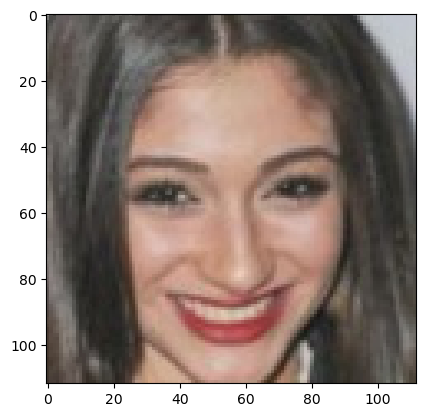

In [15]:
plt.imshow(true_pairs_1_test[1])

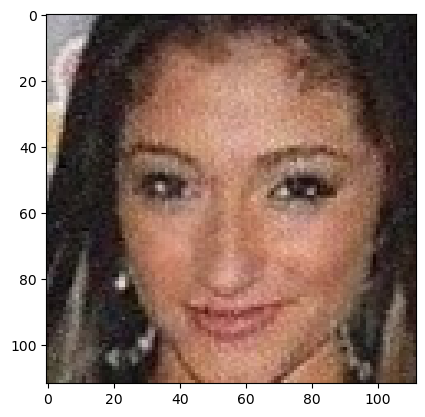

In [16]:
plt.imshow(true_pairs_2_test[1])